In [1]:
import os
import random
import numpy as np
import cv2
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from sklearn.model_selection import train_test_split

In [2]:
# Data Loading with Class Balance
# -----------------------------
def load_and_sample_images_weighted(base_path, total_samples):
    images = []
    labels = []
    class_names = []
    class_distributions = {}

    for label, folder in enumerate(sorted(os.listdir(base_path))):
        class_names.append(folder)
        folder_path = os.path.join(base_path, folder)
        class_images = []
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (128, 128))
            class_images.append(img.flatten())
        class_distributions[label] = class_images

    num_classes = len(class_distributions)
    samples_per_class = total_samples // num_classes

    for label, imgs in class_distributions.items():
        sample_size = min(samples_per_class, len(imgs))
        sampled_images = random.sample(imgs, sample_size)
        images.extend(sampled_images)
        labels.extend([label] * sample_size)

    return np.array(images), np.array(labels), class_names


In [3]:
# PINN Model
# -----------------------------
class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(64, activation='tanh')
        self.dense2 = tf.keras.layers.Dense(64, activation='tanh')
        self.dense3 = tf.keras.layers.Dense(2)
        self.c1 = tf.Variable(2.0, trainable=True, dtype=tf.float32)
        self.c3 = tf.Variable(-0.2, trainable=True, dtype=tf.float32)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.dense3(x)

# -----------------------------
# Differentiable Laplacian in TensorFlow
# -----------------------------
def laplacian_tf(u, h=1.0):
    u_xx = (tf.roll(u, shift=-1, axis=1) - 2*u + tf.roll(u, shift=1, axis=1)) / (h**2)
    u_yy = (tf.roll(u, shift=-1, axis=0) - 2*u + tf.roll(u, shift=1, axis=0)) / (h**2)
    return u_xx + u_yy


In [4]:
# CLG PDE Loss for PINN
# -----------------------------
def pinn_loss(model, image):
    h, w = image.shape
    grid_x, grid_y = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
    coords = np.stack([grid_x.flatten(), grid_y.flatten()], axis=-1).astype(np.float32)
    inputs = tf.convert_to_tensor(coords)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(model.c1)
        tape.watch(model.c3)

        outputs = model(inputs)
        v1 = tf.reshape(outputs[:, 0], (h, w))
        v2 = tf.reshape(outputs[:, 1], (h, w))

        v1_lap = laplacian_tf(v1)
        v2_lap = laplacian_tf(v2)

        v_sq = v1**2 + v2**2

        # Full CLG residuals
        res1 = v1_lap + model.c1 * v1 - (v1 - model.c3 * v2) * v_sq
        res2 = v2_lap + model.c1 * v2 - (model.c3 * v1 + v2) * v_sq

        loss = tf.reduce_mean(res1**2 + res2**2)

    return loss


In [6]:
# Train PINN for one ECG image
# -----------------------------
def learn_equation_parameters_pinn(ecg_image, epochs=50):
    img = ecg_image / 255.0
    model = PINN()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            tape.watch(model.c1)
            tape.watch(model.c3)
            loss = pinn_loss(model, img)
        grads = tape.gradient(loss, [model.c1, model.c3] + model.trainable_variables)
        optimizer.apply_gradients(zip(grads, [model.c1, model.c3] + model.trainable_variables))

    return float(model.c1.numpy()), float(model.c3.numpy())


In [7]:
# Paths
# -----------------------------
train_path = r"F:\fatemeh\phd\lesson\Linear Algebra\project\archive (4)\ECG_Image_data\train"
test_path = r"F:\fatemeh\phd\lesson\Linear Algebra\project\archive (4)\ECG_Image_data\test"
total_train_samples = 6000
total_test_samples = 1200


In [8]:
# Step 1: Load Data
# -----------------------------
X_train, y_train, class_names = load_and_sample_images_weighted(train_path, total_train_samples)
X_test, y_test, _ = load_and_sample_images_weighted(test_path, total_test_samples)

X_train_imgs = X_train.reshape(-1, 128, 128)
X_test_imgs = X_test.reshape(-1, 128, 128)


In [9]:
# Step 2: Extract PINN Features
# -----------------------------
print("[3] Extracting PINN parameters for training set...")
X_train_params = np.array([learn_equation_parameters_pinn(img) for img in X_train_imgs])

print("[3] Extracting PINN parameters for test set...")
X_test_params = np.array([learn_equation_parameters_pinn(img) for img in X_test_imgs])


[3] Extracting PINN parameters for training set...
[3] Extracting PINN parameters for test set...


In [10]:
# -----------------------------
# c1 و c3
# -----------------------------
def print_pinn_stats(params, set_name):
    c1_values = params[:, 0]
    c3_values = params[:, 1]
    print(f"\n[{set_name} PINN Parameters Statistics]")
    print(f"c1 -> Mean: {np.mean(c1_values):.4f}, Std: {np.std(c1_values):.4f}, Min: {np.min(c1_values):.4f}, Max: {np.max(c1_values):.4f}")
    print(f"c3 -> Mean: {np.mean(c3_values):.4f}, Std: {np.std(c3_values):.4f}, Min: {np.min(c3_values):.4f}, Max: {np.max(c3_values):.4f}")

print_pinn_stats(X_train_params, "Train")
print_pinn_stats(X_test_params, "Test")



[Train PINN Parameters Statistics]
c1 -> Mean: 1.8567, Std: 0.0620, Min: 1.5632, Max: 2.0121
c3 -> Mean: -0.1090, Std: 0.0229, Min: -0.1491, Max: 0.0362

[Test PINN Parameters Statistics]
c1 -> Mean: 1.8543, Std: 0.0605, Min: 1.5699, Max: 2.0107
c3 -> Mean: -0.1086, Std: 0.0227, Min: -0.1434, Max: 0.0232



[PINN Parameter Summary]
  Parameter      Mean       Std       Min       Max
0  Train c1  1.856729  0.061983  1.563187  2.012134
1  Train c3 -0.108958  0.022901 -0.149117  0.036243
2   Test c1  1.854250  0.060478  1.569876  2.010693
3   Test c3 -0.108561  0.022668 -0.143384  0.023196


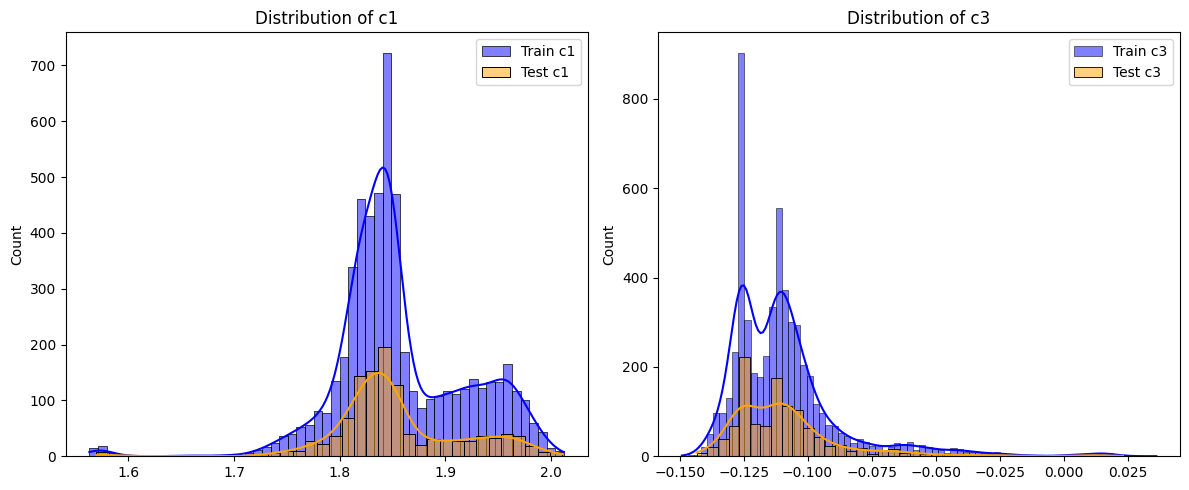

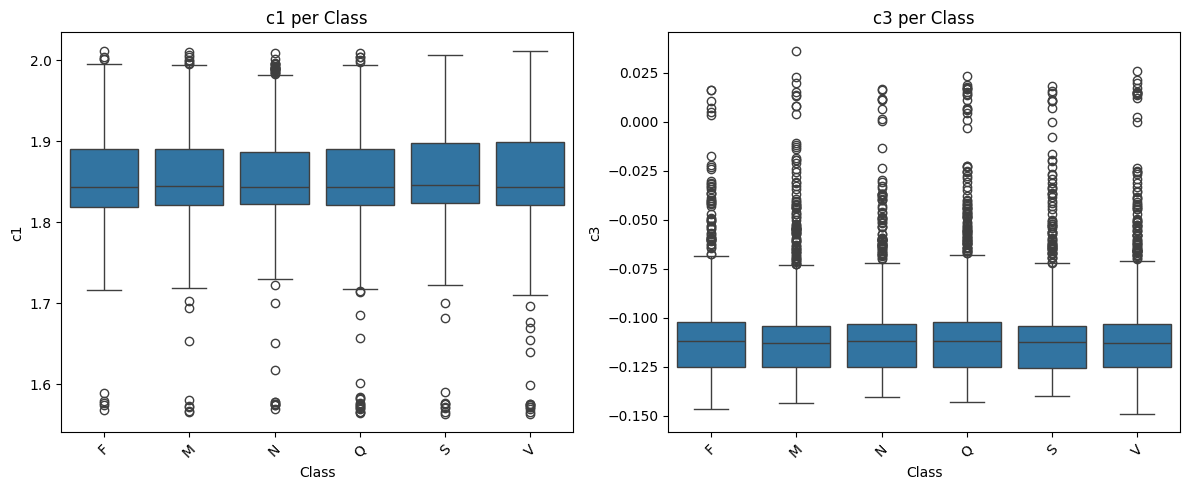

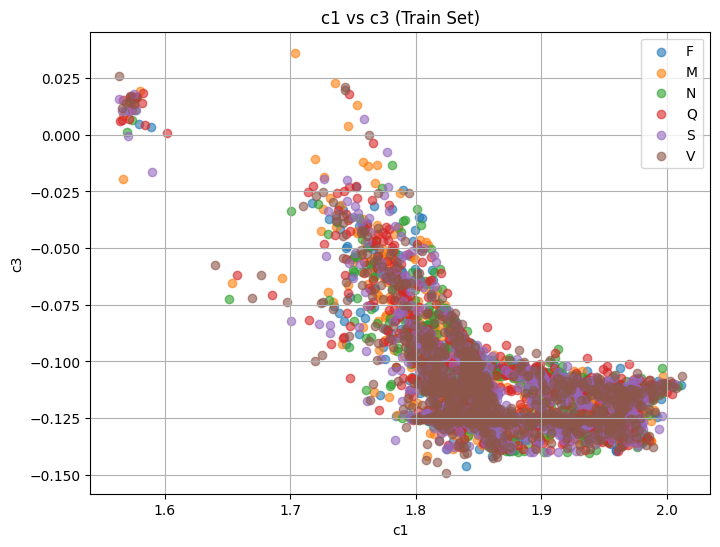

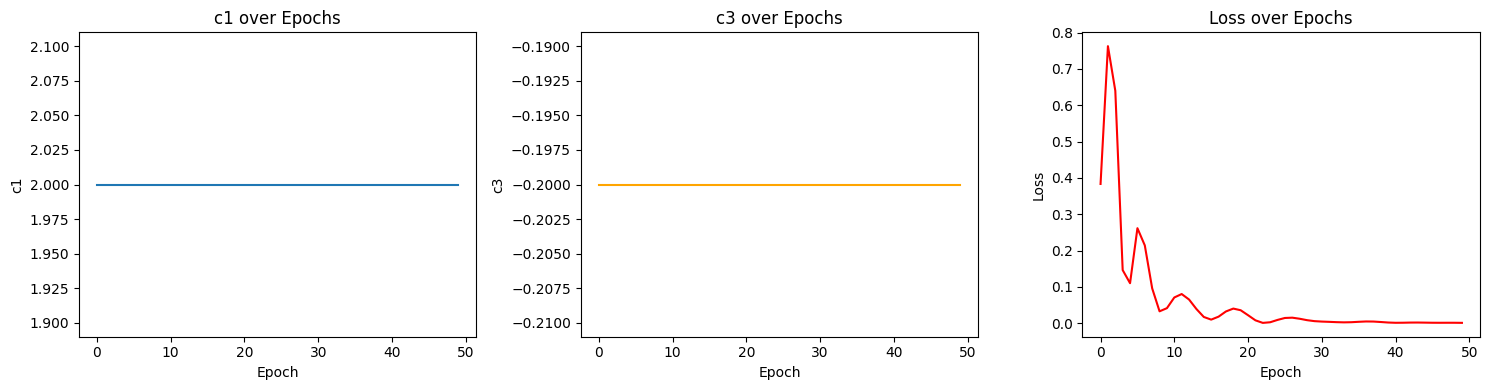

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# -----------------------------
def plot_pinn_parameter_stats(X_train_params, X_test_params, y_train, y_test, class_names):
    train_c1, train_c3 = X_train_params[:, 0], X_train_params[:, 1]
    test_c1, test_c3 = X_test_params[:, 0], X_test_params[:, 1]

    def summary_stats(name, values):
        return {
            'Parameter': name,
            'Mean': np.mean(values),
            'Std': np.std(values),
            'Min': np.min(values),
            'Max': np.max(values)
        }

   
    stats_df = pd.DataFrame([
        summary_stats("Train c1", train_c1),
        summary_stats("Train c3", train_c3),
        summary_stats("Test c1", test_c1),
        summary_stats("Test c3", test_c3),
    ])
    print("\n[PINN Parameter Summary]")
    print(stats_df)

   
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(train_c1, color="blue", kde=True, label="Train c1")
    sns.histplot(test_c1, color="orange", kde=True, label="Test c1")
    plt.legend()
    plt.title("Distribution of c1")

    plt.subplot(1, 2, 2)
    sns.histplot(train_c3, color="blue", kde=True, label="Train c3")
    sns.histplot(test_c3, color="orange", kde=True, label="Test c3")
    plt.legend()
    plt.title("Distribution of c3")
    plt.tight_layout()
    plt.show()

  
    df_box = pd.DataFrame({
        'c1': np.concatenate([train_c1, test_c1]),
        'c3': np.concatenate([train_c3, test_c3]),
        'Class': [class_names[i] for i in np.concatenate([y_train, y_test])]
    })
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_box, x='Class', y='c1')
    plt.xticks(rotation=45)
    plt.title("c1 per Class")
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_box, x='Class', y='c3')
    plt.xticks(rotation=45)
    plt.title("c3 per Class")
    plt.tight_layout()
    plt.show()


# -----------------------------
def plot_c1_c3_scatter(X_train_params, y_train, class_names):
    plt.figure(figsize=(8, 6))
    for idx, name in enumerate(class_names):
        mask = (y_train == idx)
        plt.scatter(X_train_params[mask, 0], X_train_params[mask, 1], label=name, alpha=0.6)
    plt.xlabel("c1")
    plt.ylabel("c3")
    plt.title("c1 vs c3 (Train Set)")
    plt.legend()
    plt.grid(True)
    plt.show()


# -----------------------------
def train_single_pinn_with_tracking(ecg_image, epochs=50):
    img = ecg_image / 255.0
    model = PINN()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    c1_history = []
    c3_history = []
    loss_history = []

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            loss = pinn_loss(model, img)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        c1_history.append(model.c1.numpy())
        c3_history.append(model.c3.numpy())
        loss_history.append(loss.numpy())

    return c1_history, c3_history, loss_history

def plot_single_pinn_training(X_train_imgs):
    c1_hist, c3_hist, loss_hist = train_single_pinn_with_tracking(X_train_imgs[0], epochs=50)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(c1_hist)
    ax[0].set_title("c1 over Epochs")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("c1")

    ax[1].plot(c3_hist, color="orange")
    ax[1].set_title("c3 over Epochs")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("c3")

    ax[2].plot(loss_hist, color="red")
    ax[2].set_title("Loss over Epochs")
    ax[2].set_xlabel("Epoch")
    ax[2].set_ylabel("Loss")
    plt.tight_layout()
    plt.show()


# -----------------------------
plot_pinn_parameter_stats(X_train_params, X_test_params, y_train, y_test, class_names)
plot_c1_c3_scatter(X_train_params, y_train, class_names)
plot_single_pinn_training(X_train_imgs)


In [32]:
# Step 3: PCA Features
# -----------------------------
print("[4] Performing PCA...")
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


[4] Performing PCA...


In [33]:
# Step 4: Combine Features
# -----------------------------
X_train_combined = np.hstack((X_train_params, X_train_pca))
X_test_combined = np.hstack((X_test_params, X_test_pca))


In [44]:
# Step 5: Classifier Model
# -----------------------------
input_features = Input(shape=(X_train_combined.shape[1],))
x = layers.Dense(128, activation='relu')(input_features)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=input_features, outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

model.fit(X_train_combined, y_train, epochs=80, validation_data=(X_test_combined, y_test))


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 52)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20441 (Dense)             │ (None, 128)            │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20442 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20443 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20444 (Dense)             │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,318 (67.65 KB)

 Trainable params: 17,318 (67.65 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/80
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6315 - loss: 24.9340 - val_accuracy: 0.8587 - val_loss: 3.4795
Epoch 2/80
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9077 - loss: 1.5342 - val_accuracy: 0.8854 - val_loss: 2.4295
Epoch 3/80
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9272 - loss: 0.9164 - val_accuracy: 0.8906 - val_loss: 2.0026
Epoch 4/80
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9488 - loss: 0.4973 - val_accuracy: 0.8992 - val_loss: 1.7619
Epoch 5/80
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9720 - loss: 0.2027 - val_accuracy: 0.9027 - val_loss: 1.9123
Epoch 6/80
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9743 - loss: 0.1830 - val_accuracy: 0.9001 - val_loss: 1.8040
Epoch 7/80
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9766 - loss: 0.1564 - val_accuracy: 0.9156 - val_loss: 1.5902
Epoch 8/80
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9843 - loss: 0.0912 - val_accura

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Test Accuracy: 0.9543

 Classification Report:
              precision    recall  f1-score   support

           F       0.95      0.94      0.94       161
           M       0.96      0.98      0.97       200
           N       0.96      0.98      0.97       200
           Q       1.00      0.99      1.00       200
           S       0.94      0.90      0.92       200
           V       0.92      0.93      0.93       200

    accuracy                           0.95      1161
   macro avg       0.95      0.95      0.95      1161
weighted avg       0.95      0.95      0.95      1161



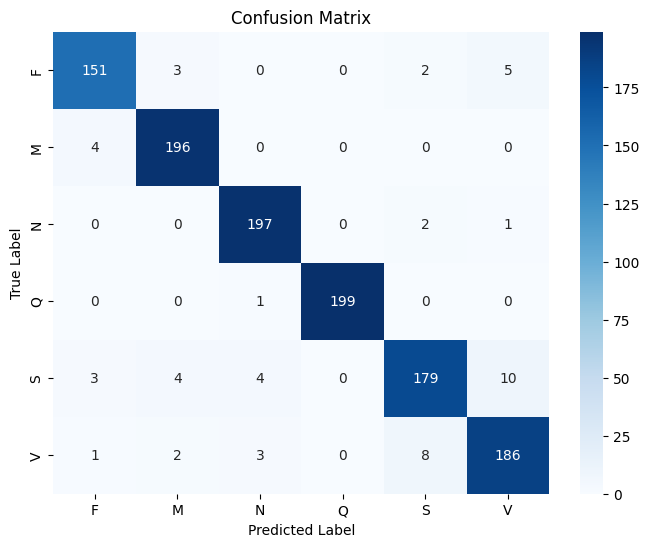

In [45]:
# Evaluation
# -----------------------------
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_combined)
y_pred_labels = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_labels)
print(f"\n Test Accuracy: {accuracy:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_labels, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


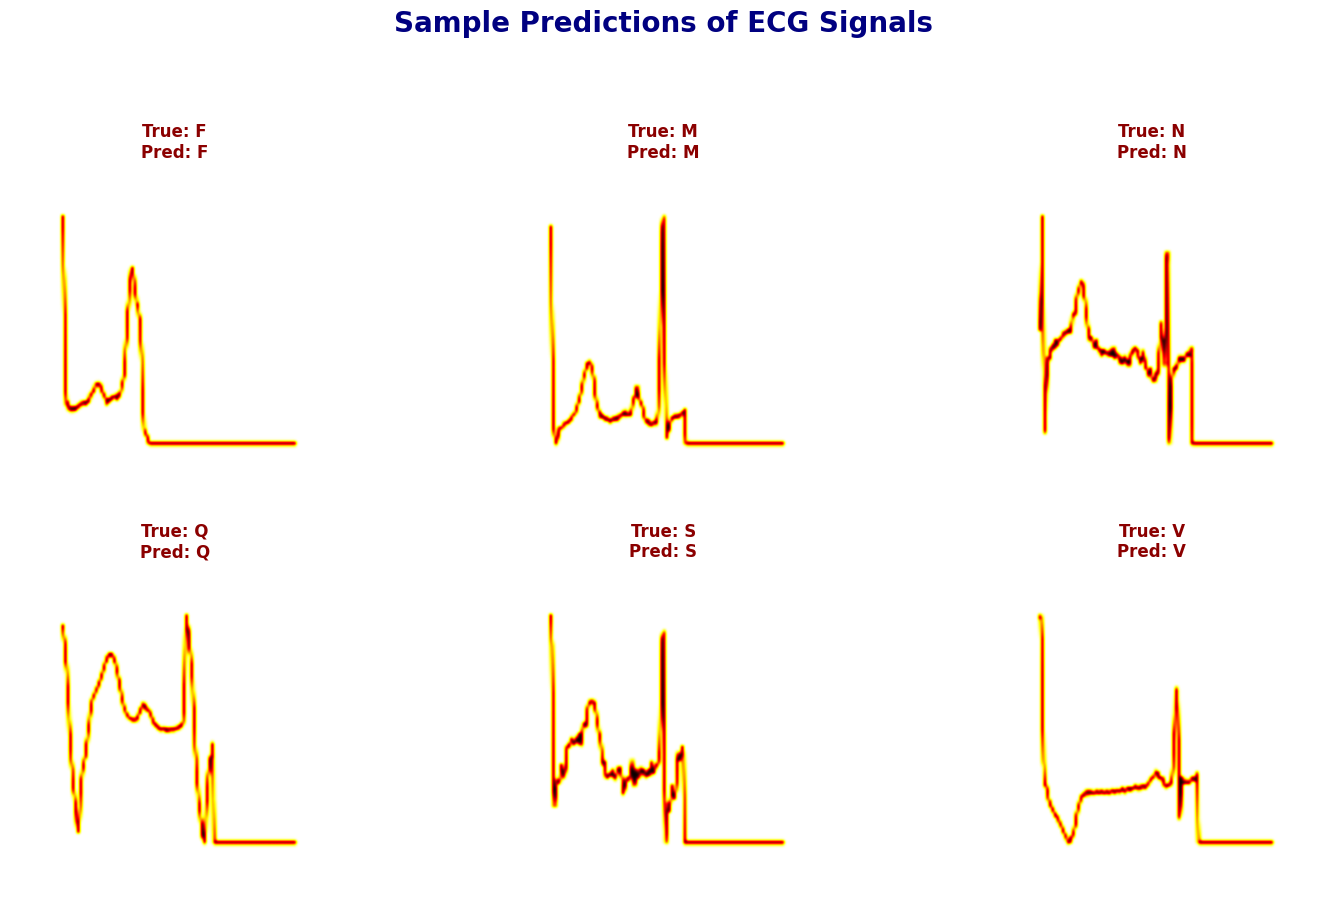

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


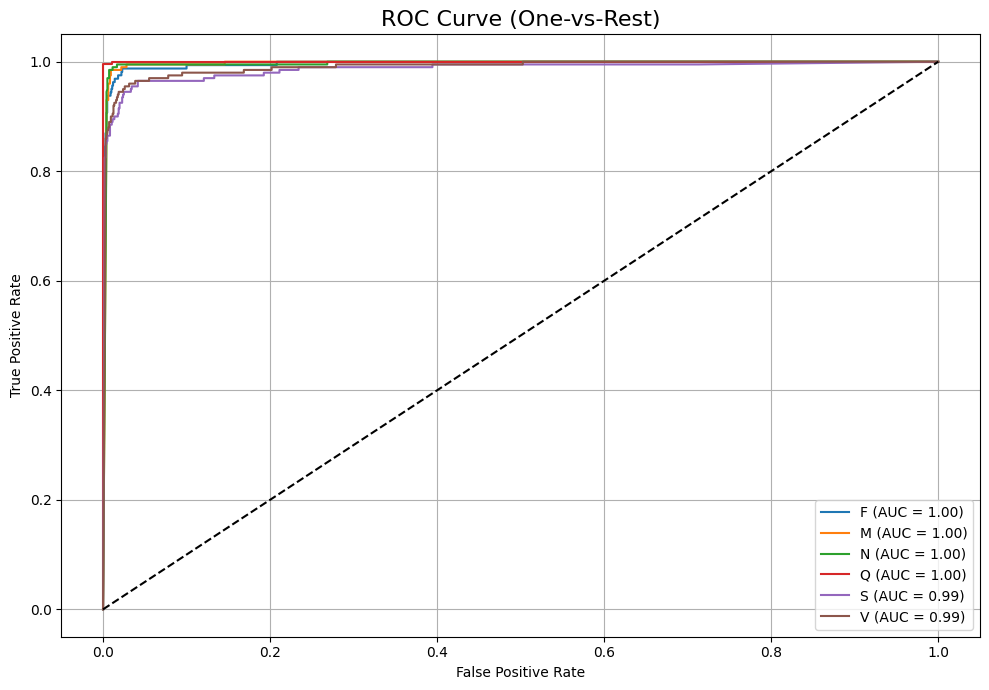

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# -----------------------------
# Function to Show Sample Predictions
# -----------------------------
def show_sample_predictions(images, labels, predictions, class_names, rows=2, cols=3):
    plt.figure(figsize=(15, 10))
    plt.suptitle('Sample Predictions of ECG Signals', fontsize=20, color='navy', weight='bold', y=0.92)

    # Group indices by class
    class_samples = {i: [] for i in range(len(class_names))}
    for i in range(len(images)):
        class_samples[labels[i]].append(i)

    # Randomly select one sample from each class
    selected_indices = []
    for i in range(len(class_names)):
        if class_samples[i]:
            selected_indices.append(np.random.choice(class_samples[i]))

    # Display images
    for i, idx in enumerate(selected_indices):
        plt.subplot(rows, cols, i + 1)
        img = images[idx].reshape(128, 128)
        plt.imshow(img, cmap='hot', interpolation='bicubic')

        plt.title(
            f"True: {class_names[labels[idx]]}\nPred: {class_names[predictions[idx]]}",
            fontsize=12,
            color='darkred',
            weight='bold'
        )

        plt.axis('off')
        plt.gca().set_facecolor('#f7f7f7')
        for side in ['top', 'right', 'left', 'bottom']:
            plt.gca().spines[side].set_visible(False)

    plt.tight_layout(pad=2.5, rect=[0, 0, 1, 0.9])
    plt.show()
    # Show Predictions on Test Set
# -----------------------------
y_pred = np.argmax(model.predict(X_test_combined), axis=1)
show_sample_predictions(X_test, y_test, y_pred, class_names)

# -----------------------------
# ROC Curve for Multi-class Classification
# -----------------------------
y_pred_probs = model.predict(X_test_combined)

# Binarize the test labels
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# بررسی آماری پارامترهای c1 و c3
# -----------------------------
def print_pinn_stats(params, set_name):
    c1_values = params[:, 0]
    c3_values = params[:, 1]
    print(f"\n[{set_name} PINN Parameters Statistics]")
    print(f"c1 -> Mean: {np.mean(c1_values):.4f}, Std: {np.std(c1_values):.4f}, Min: {np.min(c1_values):.4f}, Max: {np.max(c1_values):.4f}")
    print(f"c3 -> Mean: {np.mean(c3_values):.4f}, Std: {np.std(c3_values):.4f}, Min: {np.min(c3_values):.4f}, Max: {np.max(c3_values):.4f}")

print_pinn_stats(X_train_params, "Train")
print_pinn_stats(X_test_params, "Test")
